In [1]:
import anndata as ad
import mingl as mg
import mingl.tl.gmm_gpu as gpu_gmm

import pandas as pd
import numpy as np

from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import seaborn as sns

import itertools
import time
import re

In [2]:
"""
probabilities.py

Stage 1 of the gradient workflow.

This module reproduces notebook Sections 1–9 exactly.

Workflow
--------
Raw dataset
    ↓
Centroid calculation
    ↓
GPU GMM (k = 10)
    ↓
Probability dataframe
    ↓
Gradient score dataframe (df_score)

This stage is run ONCE per dataset.
"""

import numpy as np
import pandas as pd

import mingl as mg
import mingl.tl.gmm_gpu as gpu_gmm


##############################################################################
# Load dataset
##############################################################################

def load_dataset(file_path):
    """
    Load a synthetic dataset.

    Parameters
    ----------
    file_path : str

    Returns
    -------
    AnnData
    """

    cells = mg.pp.read_file(file_path)

    cells.obs["cell_type"] = (
        cells.obs["cell_type"]
        .astype(str)
    )

    return cells


##############################################################################
# Compute neighborhood centroids
##############################################################################

def compute_centroids(
    cells,
    cluster_col="cell_type",
    neighborhood_col="Neighborhood",
    region_key="unique_region",
):
    """
    Compute neighborhood centroids.

    Matches notebook exactly.
    """

    centroids = mg.tl.centroid_Calculation(

        cells,

        cluster_col=cluster_col,

        neighborhood_col=neighborhood_col,

        region_col=region_key,

        store_key="neighborhood_centroids",

    )

    return centroids


##############################################################################
# Compute neighborhood probabilities
##############################################################################

def compute_probabilities(
    cells,
    centroids,
    cluster_col="cell_type",
    neighborhood_col="Neighborhood",
    region_key="unique_region",
):
    """
    Compute neighborhood probabilities.

    IMPORTANT
    ---------
    The notebook fixes the GMM neighborhood size to k=10.

    We intentionally preserve that behaviour.
    """

    gpu_gmm.gpu_gmm_probability(

        cells,

        centroids,

        cluster_col=cluster_col,

        neighborhood_col=neighborhood_col,

        region_key=region_key,

        k=10,

        batch_size=20000,

        prob_key="neighborhood_probabilities",

        prob_variable_key=(
            "neighborhood_probability_neighborhoods"
        ),

    )

    mg.tl.findPositives(cells)

    return cells


##############################################################################
# Probability dataframe
##############################################################################

def compute_probability_dataframe(cells):
    """
    Convert probability matrix into
    a pandas dataframe.
    """

    df_probabilities = pd.DataFrame(

        cells.obsm["neighborhood_probabilities"],

        index=cells.obs_names,

        columns=cells.uns[
            "neighborhood_probability_neighborhoods"
        ],

    )

    return df_probabilities


##############################################################################
# Compute gradient scores
##############################################################################

def compute_scores(
    cells,
    probability_df,
    inner="A",
    outer="B",
):
    """
    Compute probability-ratio score.

    Returns
    -------
    df_score
    """

    extra_cols = [

        "x",

        "y",

        "unique_region",

        "Neighborhood",

        "cell_type",

        "true_organization",

    ]

    df = cells.obs[
        extra_cols
    ].copy()

    ##############################################################

    df[inner] = probability_df[inner]

    df[outer] = probability_df[outer]

    ##############################################################

    eps = 1e-9

    df["ratio"] = (

        (df[inner] + eps)

        /

        (df[outer] + eps)

    )

    df["log_ratio"] = np.log(
        df["ratio"]
    )

    df["max_prob"] = df[
        [inner, outer]
    ].max(axis=1)

    df["Score"] = (

        df["log_ratio"]

        *

        df["max_prob"]

    )

    return df


##############################################################################
# Complete preprocessing pipeline
##############################################################################

def prepare_gradient_input(
    file_path,
    inner="A",
    outer="B",
):
    """
    Complete preprocessing pipeline.

    This should be run ONCE for each dataset.

    Returns
    -------
    cells

    probability_df

    df_score
    """

    ##############################################################
    # Load data
    ##############################################################

    cells = load_dataset(
        file_path
    )

    ##############################################################

    centroids = compute_centroids(
        cells
    )

    ##############################################################

    cells = compute_probabilities(

        cells,

        centroids,

    )

    ##############################################################

    probability_df = compute_probability_dataframe(
        cells
    )

    ##############################################################

    df_score = compute_scores(

        cells,

        probability_df,

        inner=inner,

        outer=outer,

    )

    ##############################################################

    return (

        cells,

        probability_df,

        df_score,

    )

In [3]:
cells, probability_df, df_score = prepare_gradient_input(
    r"Z:\MINGLE\Reviewer Response\Code\R1.5\synthetic_tissue_fast.csv"
)

print(df_score["Score"].describe())

print(df_score.head())

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWar

Example dummy cols: ['cell_type__1', 'cell_type__10', 'cell_type__11', 'cell_type__12', 'cell_type__2']
{5:                x           y  unique_region cell_type    1   10   11   12  \
0     850.585467  931.366005              1         2  0.0  0.0  0.0  0.0   
1     451.564956  166.936956              1        11  0.0  1.0  1.0  0.0   
2     248.735975  591.645276              1        12  2.0  0.0  0.0  1.0   
3     584.153406  326.727948              1         4  0.0  0.0  0.0  0.0   
4     663.688130  711.389394              1         4  0.0  0.0  0.0  0.0   
...          ...         ...            ...       ...  ...  ...  ...  ...   
3335  239.822385   29.471294              1         3  2.0  1.0  0.0  0.0   
3336  442.628147  727.556213              1         7  1.0  0.0  0.0  0.0   
3337  440.154406  240.954546              1         1  1.0  0.0  2.0  0.0   
3338    3.745708  397.898635              1        10  0.0  2.0  1.0  2.0   
3339  299.828615  844.098963              1  

In [4]:
"""
binning.py

Assign probability bins to the fixed Score values.

Input
-----
df_score

Output
------
df_bins
"""

import numpy as np
import pandas as pd


##############################################################################
# Percentile labels
##############################################################################

def _percentile_labels(n_bins):
    """
    Generate percentile labels.

    Example
    -------
    n_bins = 5

    Returns
    -------
    [
        "20th percentile",
        "40th percentile",
        "60th percentile",
        "80th percentile",
        "100th percentile"
    ]
    """

    step = 100 / n_bins

    return [

        f"{int((i + 1) * step)}th percentile"

        for i in range(n_bins)

    ]


##############################################################################
# Equal-width probability bins
##############################################################################

def assign_probability_level_equal_width(
    series,
    n_bins=5,
):
    """
    Split a continuous score into equal-width bins.

    Parameters
    ----------
    series : pandas.Series

    n_bins : int

    Returns
    -------
    Probability_Level

    edges
    """

    idx = series.index

    s_non_na = series.dropna()

    ##############################################################

    if len(s_non_na) == 0:

        labels = _percentile_labels(n_bins)

        cat = pd.Series(

            pd.Categorical(

                [np.nan] * len(series),

                categories=labels,

                ordered=True,

            ),

            index=idx,

        )

        return cat, np.array([])

    ##############################################################

    min_val = float(s_non_na.min())

    max_val = float(s_non_na.max())

    ##############################################################

    if min_val == max_val:

        labels = _percentile_labels(1)

        cat = pd.Series(

            pd.Categorical(

                [

                    labels[0]

                    if not pd.isna(v)

                    else np.nan

                    for v in series

                ],

                categories=labels,

                ordered=True,

            ),

            index=idx,

        )

        return cat, np.array([min_val, max_val])

    ##############################################################

    edges = np.linspace(

        min_val,

        max_val,

        n_bins + 1,

    )

    labels = _percentile_labels(n_bins)

    ##############################################################

    probability_level = pd.cut(

        series,

        bins=edges,

        labels=labels,

        include_lowest=True,

    )

    return probability_level, edges


##############################################################################
# Wrapper
##############################################################################

def prepare_probability_bins(
    df_score,
    n_bins,
):
    """
    Add Probability_Level to the score dataframe.

    Parameters
    ----------
    df_score

    n_bins

    Returns
    -------
    df_bins

    edges
    """

    df_bins = df_score.copy()

    (

        df_bins["Probability_Level"],

        edges,

    ) = assign_probability_level_equal_width(

        df_bins["Score"],

        n_bins=n_bins,

    )

    return df_bins, edges


##############################################################################
# Diagnostics
##############################################################################

def summarize_probability_bins(
    df_bins,
):
    """
    Print summary of the probability bins.
    """

    print()

    print("Probability Bin Counts")

    print("----------------------")

    print(

        df_bins["Probability_Level"]

        .value_counts()

        .sort_index()

    )

    print()

    return

In [5]:
df_bins, edges = prepare_probability_bins(
    df_score,
    n_bins=5,
)

summarize_probability_bins(df_bins)

print(edges)

display(df_bins.head())


Probability Bin Counts
----------------------
Probability_Level
20th percentile     1655
40th percentile       14
60th percentile       15
80th percentile       13
100th percentile    1643
Name: count, dtype: int64

[-20.72326584 -12.4339595   -4.14465317   4.14465317  12.4339595
  20.72326584]


,x,y,unique_region,Neighborhood,cell_type,true_organization,A,B,ratio,log_ratio,max_prob,Score,Probability_Level
0,850.585467,931.366005,1,B,2,B,3.867500e-46,1.000000e+00,1.000000e-09,-20.723266,1.0,-20.723266,20th percentile
1,451.564956,166.936956,1,A,11,A,1.000000e+00,9.061916e-23,1.000000e+09,20.723266,1.0,20.723266,100th percentile
2,248.735975,591.645276,1,A,12,A,1.000000e+00,4.674585e-39,1.000000e+09,20.723266,1.0,20.723266,100th percentile
3,584.153406,326.727948,1,B,4,B,2.695486e-39,1.000000e+00,1.000000e-09,-20.723266,1.0,-20.723266,20th percentile
4,663.688130,711.389394,1,B,4,B,3.867500e-46,1.000000e+00,1.000000e-09,-20.723266,1.0,-20.723266,20th percentile


In [6]:
"""
gradient_analysis.py

Downstream gradient analysis.

This module is a direct extraction of notebook Sections 11–20.

Nothing in this module recomputes MINGL probabilities.

Input
-----
df_score

Output
------
Gradient statistics.
"""

import time
import numpy as np
import pandas as pd

import anndata as ad
import mingl as mg

from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression


##############################################################################
# SECTION 11–12
##############################################################################

def prepare_window_dataframe(df_bins):
    """
    Prepare dataframe exactly as in notebook Sections 11–12.
    """

    df = df_bins.copy()

    ##############################################################
    # Notebook variables
    ##############################################################

    cluster_col = "Probability_Level"

    X = "x"
    Y = "y"

    reg = "unique_region"

    neigh = "Neighborhood"

    celltype = "Cell Type"

    ##############################################################
    # EXACT notebook code
    ##############################################################

    if cluster_col not in df.columns:

        raise KeyError(
            f"Column '{cluster_col}' not found."
        )

    dummies = pd.get_dummies(
        df[cluster_col],
        dtype=int,
    )

    df = pd.concat(
        [df, dummies],
        axis=1,
    )

    sum_cols = dummies.columns.tolist()

    ##############################################################

    df["Cell Type"] = (
        df["cell_type"]
        .astype(str)
    )

    df["Community"] = "None"

    df["Tissue Unit"] = "None"

    df["unique_region"] = (
        df["unique_region"]
        .astype(str)
    )

    ##############################################################

    return (

        df,

        sum_cols,

        X,

        Y,

        reg,

        neigh,

        celltype,

        cluster_col,

    )

In [7]:
##############################################################################
# ORIGINAL NOTEBOOK CLASS
##############################################################################

class Neighborhoods(object):

    def __init__(
        self,
        cells,
        ks,
        cluster_col,
        sum_cols,
        keep_cols,
        neigh,
        X='X:X',
        Y='Y:Y',
        reg='Exp',
        add_dummies=True,
    ):

        self.cells_nodumz = cells

        self.X = X
        self.Y = Y

        self.reg = reg

        self.keep_cols = keep_cols

        self.sum_cols = sum_cols

        self.ks = ks

        self.cluster_col = cluster_col

        self.n_neighbors = max(ks)

        self.exps = list(
            self.cells_nodumz[self.reg].unique()
        )

        self.bool_add_dummies = add_dummies

        self.neigh = neigh

    ##########################################################################

    def add_dummies(self):

        c = self.cells_nodumz

        dumz = pd.get_dummies(
            c[self.cluster_col],
            dtype=int,
        )

        keep = c[self.keep_cols]

        self.cells = pd.concat(
            [keep, dumz],
            axis=1,
        )

    ##########################################################################

    def get_tissue_chunks(self):

        self.tissue_group = (

            self.cells[
                [self.X, self.Y, self.reg]
            ]

            .groupby(self.reg)

        )

        tissue_chunks = [

            (

                time.time(),

                self.exps.index(t),

                t,

                a,

            )

            for t, indices
            in self.tissue_group.groups.items()

            for a in np.array_split(indices,1)

        ]

        return tissue_chunks

    def make_windows(self,job):
        start_time,idx,tissue_name,indices = job
        job_start = time.time()

        print ("Starting:", str(idx+1)+'/'+str(len(self.exps)),': ' + self.exps[idx])

        tissue = self.tissue_group.get_group(tissue_name)
        to_fit = tissue.loc[indices][[self.X,self.Y]].values

        fit = NearestNeighbors(n_neighbors=self.n_neighbors+1).fit(tissue[[self.X,self.Y]].values)
        m = fit.kneighbors(to_fit)
        
        #don't include index cell in window (can always easily add to windows again later by just adding 1)
        m = m[0][:,1:], m[1][:,1:]


        #sort_neighbors
        args = m[0].argsort(axis = 1)
        add = np.arange(m[1].shape[0])*m[1].shape[1]
        sorted_indices = m[1].flatten()[args+add[:,None]]
        sorted_dists = m[0].flatten()[args+add[:,None]]
        neighbors = tissue.index.values[sorted_indices].astype(np.int32)
        end_time = time.time()

        print ("Finishing:", str(idx+1)+"/"+str(len(self.exps)),": "+ self.exps[idx],end_time-job_start,end_time-start_time)
        return neighbors,sorted_dists
    
    def k_windows(self,distance_max = 'none'):
        if self.bool_add_dummies:
            self.add_dummies()
        else:
            self.cells =self.cells_nodumz
        sum_cols = list(self.sum_cols)
        for col in sum_cols:
            if col in self.keep_cols:
                self.cells[col+'_sum'] = self.cells[col]
                self.sum_cols.remove(col)
                self.sum_cols+=[col+'_sum']

        values = self.cells[self.sum_cols].values
        tissue_chunks = self.get_tissue_chunks()
        tissues = [self.make_windows(job) for job in tissue_chunks]
        
        out_dict = {}
        if distance_max == 'none':
            k_dists = {k:np.inf for k in self.ks}
        else:
            k_dists = {k: distance_max for k in self.ks}

        print("k_dists:", k_dists, "Type:", type(k_dists))
        print("distance_max:", distance_max, "Type:", type(distance_max))

        for k in self.ks:
            for (neighbors,sorted_dists),job in zip(tissues,tissue_chunks):
                chunk = np.arange(len(neighbors))#indices
                tissue_name = job[2]
                indices = job[3]
                window = values[neighbors[chunk,:k].flatten()].reshape(len(chunk),k,len(self.sum_cols))

                mask = sorted_dists>k_dists[k]
                no_cells_masked = mask.sum(1)
                avg_cells_excluded = no_cells_masked[no_cells_masked!=0]
                if len(avg_cells_excluded)>0:
                    avg_cells_excluded = avg_cells_excluded.mean()
                else:
                    avg_cells_excluded = 0
                print ('{}:{}--{}/{} cells had cells excluded.  Avg excluded={}'.format(tissue_name,k,(no_cells_masked>0).sum(),len(no_cells_masked),avg_cells_excluded))

                mask = np.repeat(mask[:, :k, np.newaxis], len(sum_cols), axis=2)# don't sum cells that are outside max_distance
                masked_window = np.ma.array(window,mask = mask)
                summed = masked_window.sum(1).data

                out_dict[(tissue_name,k)] = (summed.astype(np.float16),indices)
        
        windows = {}
    
        for k in self.ks:

            window = pd.concat([pd.DataFrame(out_dict[(exp,k)][0],index = out_dict[(exp,k)][1].astype(int),columns = self.sum_cols) for exp in self.exps],axis=0)
            self.cells.index = self.cells.index.astype(int)
            window = window.loc[self.cells.index.values]
            window = pd.concat([self.cells[self.keep_cols],window],axis=1)
            windows[k] = window
        return windows

In [8]:
df_bins, edges = prepare_probability_bins(
    df_score,
    n_bins=5,
)

(
    df,
    sum_cols,
    X,
    Y,
    reg,
    neigh,
    celltype,
    cluster_col,
) = prepare_window_dataframe(
    df_bins
)

print(sum_cols)
print(df.columns)

['20th percentile', '40th percentile', '60th percentile', '80th percentile', '100th percentile']
Index(['x', 'y', 'unique_region', 'Neighborhood', 'cell_type',
       'true_organization', 'A', 'B', 'ratio', 'log_ratio', 'max_prob',
       'Score', 'Probability_Level', '20th percentile', '40th percentile',
       '60th percentile', '80th percentile', '100th percentile', 'Cell Type',
       'Community', 'Tissue Unit'],
      dtype='object')


In [9]:
import re

##############################################################################
# Original notebook cluster ordering
##############################################################################

def compute_cluster_order(
    k_centroids,
    sum_cols,
    df_sub,
):
    """
    Reproduce the cluster ordering from the original notebook.

    Parameters
    ----------
    k_centroids : ndarray
        KMeans cluster centers.

    sum_cols : list
        Dummy-variable columns corresponding to probability bins.

    df_sub : DataFrame
        Filtered dataframe containing Probability_Bin_Cluster and Score.

    Returns
    -------
    ordered_clusters : list[str]
        Cluster labels in notebook order.

    means : ndarray
        Mean Score for each ordered cluster.
    """

    ##############################################################
    # Build normalized centroid dataframe
    ##############################################################

    cent_df = pd.DataFrame(
        k_centroids,
        columns=sum_cols,
    )

    cent_norm = cent_df.div(
        cent_df.sum(axis=1) + 1e-12,
        axis=0,
    )

    ##############################################################
    # Parse percentile labels
    ##############################################################

    def extract_pct(label):

        s = str(label)

        m = re.search(
            r'(\d{1,3})\s*(?:th|st|nd|rd)?\s*(?:%|\s*percentile\b)?',
            s,
            flags=re.IGNORECASE,
        )

        if m:
            return int(m.group(1))

        m = re.search(
            r'bin[_\s]*(\d+)',
            s,
            flags=re.IGNORECASE,
        )

        if m:
            return int(m.group(1))

        m = re.search(r'(\d+)$', s)

        if m:
            return int(m.group(1))

        return None

    ##############################################################
    # Determine left-to-right column order
    ##############################################################

    parsed = [
        (c, extract_pct(c))
        for c in cent_norm.columns
    ]

    cols_numeric = [
        c
        for c, v in parsed
        if v is not None
    ]

    cols_numeric = sorted(
        cols_numeric,
        key=extract_pct,
        reverse=True,
    )

    cols_other = [
        c
        for c, v in parsed
        if v is None
    ]

    desired_cols = cols_numeric + cols_other

    ##############################################################
    # Weighted ordering (identical to notebook)
    ##############################################################

    base = 2.0

    weights = np.array([

        base ** (len(desired_cols) - 1 - i)

        for i in range(len(desired_cols))

    ])

    score_vec = (
        cent_norm[desired_cols]
        .values
        .dot(weights)
    )

    order_df = pd.DataFrame(
        index=cent_norm.index
    )

    order_df["score"] = score_vec

    for c in desired_cols:

        order_df[f"cent_{c}"] = (
            -cent_norm[c].values
        )

    sort_cols = (
        ["score"]
        +
        [
            f"cent_{c}"
            for c in desired_cols
        ]
    )

    order_df = order_df.sort_values(

        by=sort_cols,

        ascending=False,

        kind="mergesort",

    )

    ordered_clusters = [
        str(i)
        for i in order_df.index
    ]

    ##############################################################
    # Compute mean score in notebook order
    ##############################################################

    agg = (
        df_sub
        .groupby(
            df_sub["Probability_Bin_Cluster"].astype(str)
        )["Score"]
        .mean()
    )

    ordered_clusters = [

        c

        for c in ordered_clusters

        if c in agg.index

    ]

    means = agg.loc[
        ordered_clusters
    ].to_numpy()

    return ordered_clusters, means

In [10]:
##############################################################################
# Downstream gradient analysis
##############################################################################

def run_gradient_analysis(
    df_bins,
    neighborhood_size,
    n_clusters,
    n_bins,
    inner="A",
    outer="B",
):
    """
    Complete downstream gradient analysis.
    """

    ##############################################################
    # Notebook Section 11–13
    ##############################################################

    (
        df,
        sum_cols,
        X,
        Y,
        reg,
        neigh,
        celltype,
        cluster_col,
    ) = prepare_window_dataframe(df_bins)

    ##############################################################

    Neigh = Neighborhoods(

        df,

        ks=[neighborhood_size],

        cluster_col=cluster_col,

        sum_cols=sum_cols,

        reg=reg,

        keep_cols=[
            X,
            Y,
            reg,
            neigh,
            celltype,
            cluster_col,
        ],

        neigh=neigh,

        X=X,

        Y=Y,

        add_dummies=True,

    )

    cluster_name_windows = Neigh.k_windows(
        distance_max=1000
    )

    ##############################################################
    # Notebook Section 14
    ##############################################################

    windows2 = cluster_name_windows[
        neighborhood_size
    ]

    if not windows2.index.equals(df.index):

        if len(windows2) == len(df):

            windows2 = windows2.reset_index(
                drop=True
            )

            df = df.reset_index(
                drop=True
            )

        else:

            raise ValueError(
                "Window indices do not match."
            )

    ##############################################################

    mask = df["Neighborhood"].isin(
        [inner, outer]
    )

    windows2_sub = windows2.loc[
        mask
    ].copy()

    df_sub = df.loc[
        mask
    ].copy()

    ##############################################################

    km = MiniBatchKMeans(

        n_clusters=n_clusters,

        random_state=0,

    )

    # Notebook fallback
    if set(sum_cols).issubset(windows2_sub.columns):

        feature_matrix = windows2_sub[
            sum_cols
        ].values

    else:

        feature_matrix = df_sub[
            sum_cols
        ].values

    labels = km.fit_predict(
        feature_matrix
    )

    # Notebook centroid storage
    k_centroids = {
        neighborhood_size: km.cluster_centers_
    }

    neighborhood_name = (
        neigh
        +
        str(neighborhood_size)
    )

    df_sub[
        neighborhood_name
    ] = labels

    df[
        neighborhood_name
    ] = -1

    df.loc[
        mask,
        neighborhood_name,
    ] = labels

    ##############################################################
    # Notebook Section 15
    ##############################################################

    values = df_sub[
        sum_cols
    ].values

    tissue_average = values.mean(
        axis=0
    )

    eps = 1e-12

    tissue_row = tissue_average.reshape(
        1,
        -1,
    )

    niche = (
        k_centroids[
            neighborhood_size
        ]
        +
        tissue_row
    )

    row_sums = niche.sum(
        axis=1,
        keepdims=True,
    )

    norm = niche / (
        row_sums
        +
        eps
    )

    fc = np.log2(

        (norm + eps)

        /

        (tissue_row + eps)

    )

    ##############################################################
    # Notebook Section 15
    ##############################################################

    mapping = {

        i: str(i)

        for i in range(
            n_clusters
        )

    }

    df_sub[
        "Probability_Bin_Cluster"
    ] = df_sub[
        neighborhood_name
    ].map(mapping)

    ##############################################################
    # Notebook Section 17
    ##############################################################

    adata = ad.AnnData(
        obs=df_sub.copy()
    )

    adata.obs_names = (
        adata.obs.index.astype(str)
    )

    mg.tl.gb(

        adata,

        cluster_key="Probability_Bin_Cluster",

        score_key="Score",

        neighborhood_key="Neighborhood",

        inner_name=inner,

        outer_name=outer,

        min_cells=0,

        pb_prefix="pb",

        region_key="unique_region",

        region_value="1",

        x_key="x",

        y_key="y",

        k_neighbors=neighborhood_size,

        normalize_by="iqr",

        grad_prefix="grad",

        make_plots=False,

    )

    ##############################################################
    # Notebook Section 20
    ##############################################################

    ordered_clusters, means = compute_cluster_order(

        k_centroids[neighborhood_size],

        sum_cols,

        df_sub,

    )

    X = np.arange(len(means)).reshape(-1, 1)

    lr = LinearRegression()

    lr.fit(X, means)

    slope = float(lr.coef_[0])

    fd = np.diff(means)

    sd = np.diff(fd)

    if len(sd):

        steepness = float(

            np.mean(

                np.abs(sd)

            )

        )

    else:

        steepness = np.nan

    ##############################################################

    stats = {

        "Steepness":
            steepness,

        "Slope":
            slope,

        "MeanScores":
            means,

        "FirstDerivative":
            fd,

        "SecondDerivative":
            sd,

    }

    return (

        df_sub,

        adata,

        stats,

    )

In [12]:
df_bins, _ = prepare_probability_bins(
    df_score,
    n_bins=5,
)

df_sub, adata, stats = run_gradient_analysis(

    df_bins,

    neighborhood_size=20,

    n_clusters=5,
    n_bins=5,

)

print(stats)

print(df_sub.head())

Starting: 1/1 : 1
Finishing: 1/1 : 1 0.012754678726196289 0.012754678726196289
k_dists: {20: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:20--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3936.56pt/s]

{'Steepness': 9.02727212842566, 'Slope': -11.432206564417427, 'MeanScores': array([ 20.70052546,  12.80798495,  -5.69023932, -18.6896155 ,
       -20.71170714]), 'FirstDerivative': array([ -7.89254051, -18.49822426, -12.99937619,  -2.02209163]), 'SecondDerivative': array([-10.60568375,   5.49884808,  10.97728456])}
            x           y unique_region Neighborhood cell_type  \
0  850.585467  931.366005             1            B         2   
1  451.564956  166.936956             1            A        11   
2  248.735975  591.645276             1            A        12   
3  584.153406  326.727948             1            B         4   
4  663.688130  711.389394             1            B         4   

  true_organization             A             B         ratio  log_ratio  ...  \
0                 B  3.867500e-46  1.000000e+00  1.000000e-09 -20.723266  ...   
1                 A  1.000000e+00  9.061916e-23  1.000000e+09  20.723266  ...   
2                 A  1.000000e+00  4.674585

Fast Dataset Sweep

In [20]:
from itertools import product
import pandas as pd

##############################################################
# Parameter ranges
##############################################################

BIN_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10]

NEIGHBORHOOD_SIZES = [
    10,
    20,
    30,
    40,
    50,
    100,
    300,
]

N_CLUSTERS = [
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
]

##############################################################

results = []

total_runs = (
    len(BIN_VALUES)
    * len(NEIGHBORHOOD_SIZES)
    * len(N_CLUSTERS)
)

run = 1

##############################################################

for n_bins, neighborhood_size, n_clusters in product(
    BIN_VALUES,
    NEIGHBORHOOD_SIZES,
    N_CLUSTERS,
):

    print(
        f"[{run}/{total_runs}] "
        f"bins={n_bins}, "
        f"window={neighborhood_size}, "
        f"clusters={n_clusters}"
    )

    ##########################################################

    df_bins, bin_edges = prepare_probability_bins(
        df_score,
        n_bins=n_bins,
    )

    ##########################################################

    try:

        df_sub, adata, stats = run_gradient_analysis(

            df_bins,

            neighborhood_size=neighborhood_size,

            n_clusters=n_clusters,
            n_bins=n_bins,

        )

        results.append({

        "Bins": n_bins,

        "Neighborhood_Size": neighborhood_size,

        "Clusters": n_clusters,

        "Slope": stats["Slope"],

        "Steepness": stats["Steepness"],

        "MeanScores": stats["MeanScores"],

        "FirstDerivative": stats["FirstDerivative"],

        "SecondDerivative": stats["SecondDerivative"],

    })

    except Exception as e:

        print("FAILED:", e)

        results.append({

            "Bins": n_bins,

            "Neighborhood_Size": neighborhood_size,

            "Clusters": n_clusters,

            "Slope": None,

            "Steepness": None,

            "MeanScores": None,

            "Error": str(e),

        })

    run += 1

##############################################################

results_df = pd.DataFrame(results)

results_df

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


[1/567] bins=2, window=10, clusters=2
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.0059163570404052734 0.0059163570404052734
k_dists: {10: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0


Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3954.43pt/s]


[2/567] bins=2, window=10, clusters=3
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.0061571598052978516 0.0061571598052978516
k_dists: {10: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3813.72pt/s]


...

[566/567] bins=10, window=300, clusters=9
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.14569497108459473 0.14569497108459473
k_dists: {300: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:300--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3898.14pt/s]


[567/567] bins=10, window=300, clusters=10
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.1451883316040039 0.1451883316040039
k_dists: {300: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:300--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3653.13pt/s]


,Bins,Neighborhood_Size,Clusters,Slope,Steepness,MeanScores,FirstDerivative,SecondDerivative
0,2,10,2,-40.467927,NaN,"[20.12280790409824, -20.3451188021125]",[-40.46792670621074],[]
1,2,10,3,-20.611043,1.845854,"[20.597762509405655, -0.9362070914192843, -20....","[-21.53396960082494, -19.68811547974927]",[1.8458541210756678]
2,2,10,4,-14.545621,11.710002,"[20.670541085192678, 12.641563086873083, -8.93...","[-8.028977998319595, -21.57162278789604, -11.6...","[-13.542644789576444, 9.877359917750443]"
3,2,10,5,-11.390368,7.191780,"[20.670541085192678, 14.819695464094087, -0.62...","[-5.850845621098591, -15.442515007777281, -15....","[-9.59166938667869, -0.37560153695567955, 11.6..."
4,2,10,6,-9.227039,5.950239,"[20.670541085192678, 14.819695464094087, 4.490...","[-5.850845621098591, -10.329622213912785, -15....","[-4.478776592814194, -5.47611994710811, 8.4301..."
...,...,...,...,...,...,...,...,...
562,10,300,6,-10.088966,10.985614,"[20.72326583794641, 20.55140027824888, 1.51743...","[-0.1718655596975296, -19.033966924357983, -22...","[-18.862101364660454, -3.0231946394970457, 21...."
563,10,300,7,-8.766602,11.267012,"[20.72326583794641, 20.72208376333779, 17.6493...","[-0.0011820746086215195, -3.0727558973390643, ...","[-3.0715738227304428, -25.095365904429826, 18...."
564,10,300,8,-7.672302,7.853604,"[20.72326583794641, 20.723265830884174, 20.677...","[-7.062237017407824e-09, -0.04544554526553313,...","[-0.04544553820329611, -1.7615238995594744, -2..."
565,10,300,9,-6.868169,6.704376,"[20.72326583794641, 20.723265830884174, 20.678...","[-7.062237017407824e-09, -0.045123236383773246...","[-0.04512322932153623, -1.9694937490573423, -2..."


probability bins

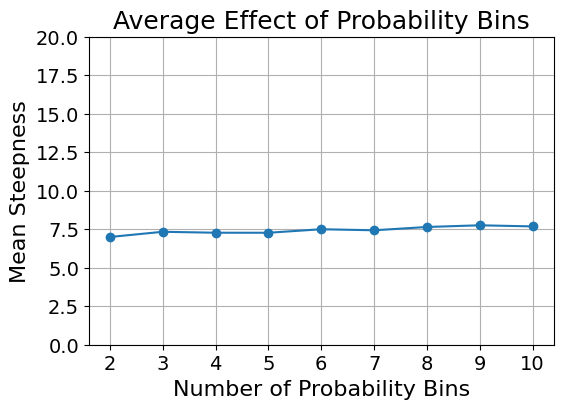

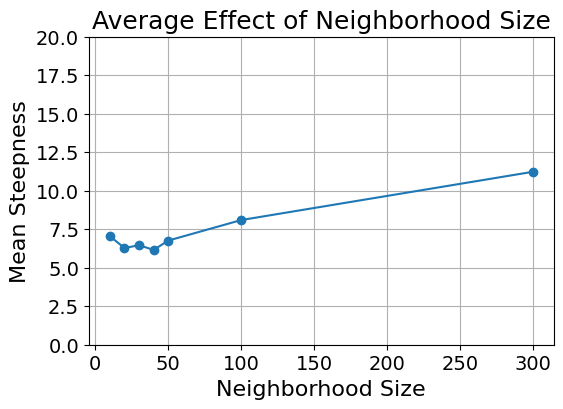

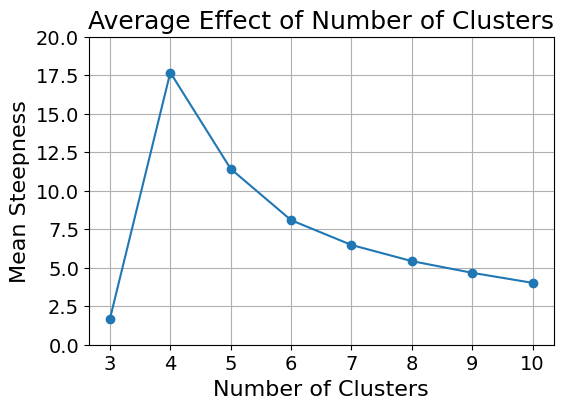

In [24]:
import matplotlib.pyplot as plt

# Font sizes
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

##############################################################
# Average steepness vs. number of bins
##############################################################

bins_summary = (
    results_df
    .groupby("Bins")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(bins_summary.index, bins_summary.values, marker="o")
plt.xlabel("Number of Probability Bins", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Probability Bins", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

##############################################################
# Average steepness vs. neighborhood size
##############################################################

window_summary = (
    results_df
    .groupby("Neighborhood_Size")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(window_summary.index, window_summary.values, marker="o")
plt.xlabel("Neighborhood Size", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Neighborhood Size", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

##############################################################
# Average steepness vs. number of clusters
##############################################################

cluster_summary = (
    results_df
    .groupby("Clusters")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(cluster_summary.index, cluster_summary.values, marker="o")
plt.xlabel("Number of Clusters", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Number of Clusters", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

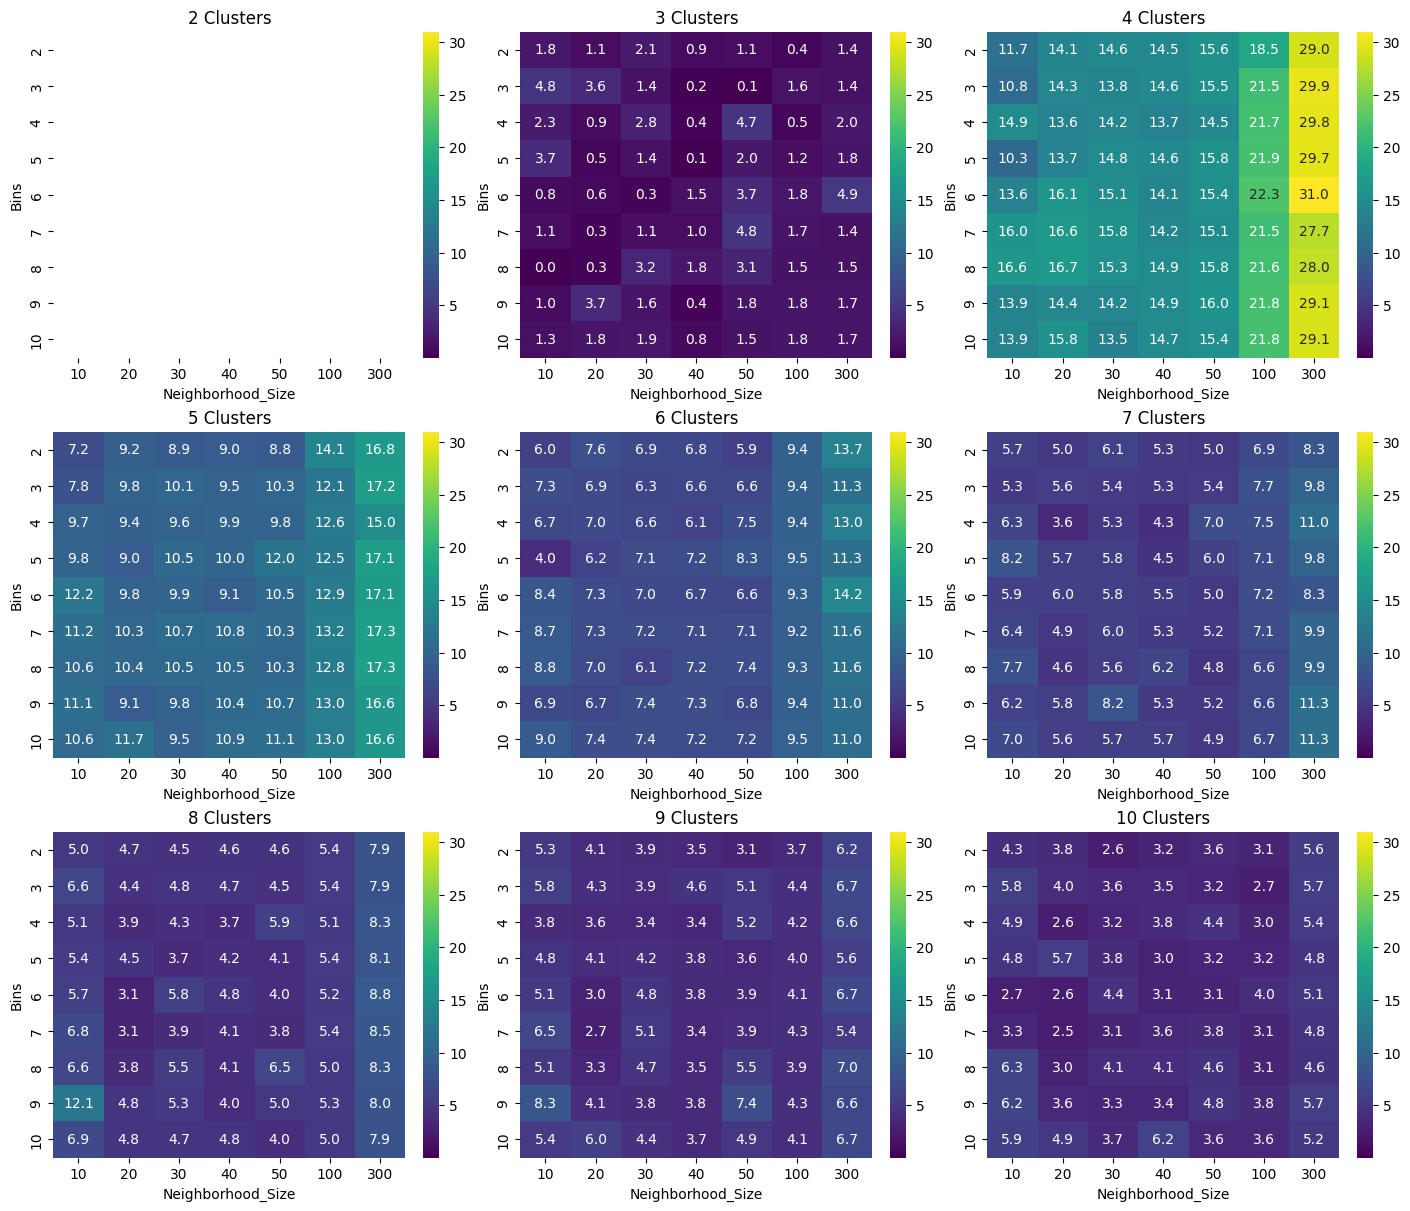

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cluster_values = sorted(results_df["Clusters"].unique())

vmin = results_df["Steepness"].min()
vmax = results_df["Steepness"].max()

fig, axes = plt.subplots(
    3,
    3,
    figsize=(14,12),
    constrained_layout=True
)

axes = axes.flatten()

for ax, c in zip(axes, cluster_values):

    pivot = (
        results_df[results_df["Clusters"] == c]
        .pivot(
            index="Bins",
            columns="Neighborhood_Size",
            values="Steepness"
        )
    )

    sns.heatmap(
        pivot,
        cmap="viridis",
        annot=True,
        fmt=".1f",
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )

    ax.set_title(f"{c} Clusters")

plt.show()

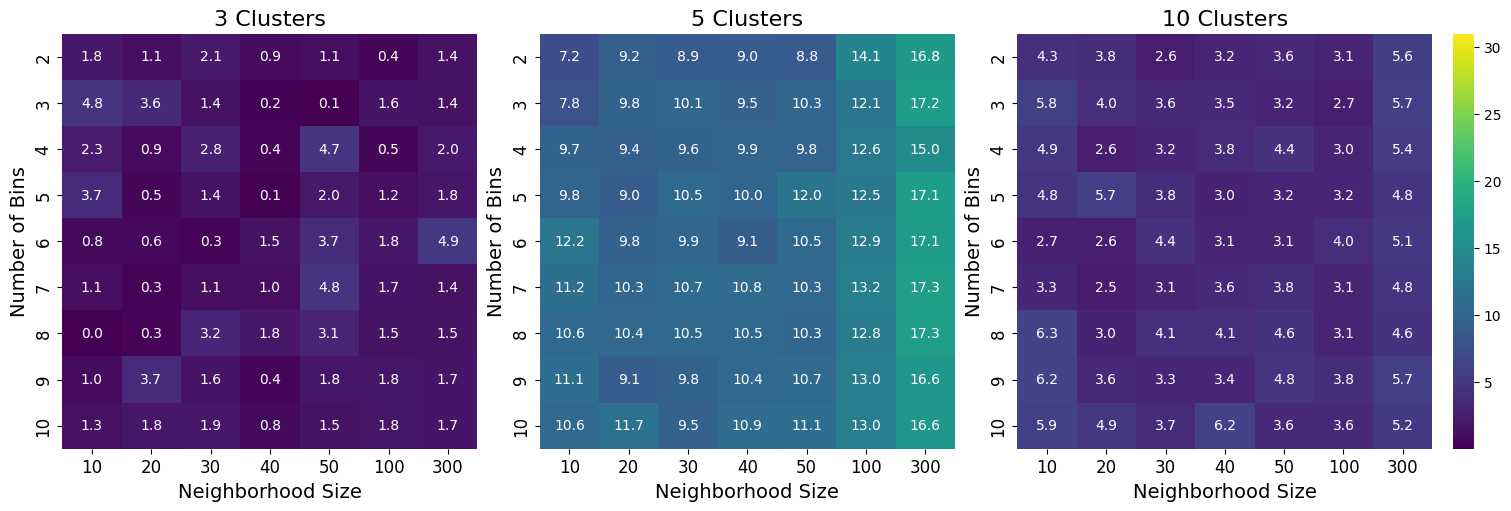

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_values = [3, 5, 10]

vmin = results_df["Steepness"].min()
vmax = results_df["Steepness"].max()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True
)

for ax, c in zip(axes, cluster_values):

    pivot = (
        results_df[results_df["Clusters"] == c]
        .pivot(
            index="Bins",
            columns="Neighborhood_Size",
            values="Steepness"
        )
    )

    sns.heatmap(
        pivot,
        cmap="viridis",
        annot=True,
        fmt=".1f",
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        cbar=(c == cluster_values[-1])  # only show one colorbar
    )

    ax.set_title(f"{c} Clusters", fontsize=16)
    ax.set_xlabel("Neighborhood Size", fontsize=14)
    ax.set_ylabel("Number of Bins", fontsize=14)
    ax.tick_params(labelsize=12)

plt.show()

Medium

In [26]:
cells, probability_df, df_score = prepare_gradient_input(
    r"Z:\MINGLE\Reviewer Response\Code\R1.5\synthetic_tissue_medium.csv"
)

print(df_score["Score"].describe())

print(df_score.head())

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWar

Example dummy cols: ['cell_type__1', 'cell_type__10', 'cell_type__11', 'cell_type__12', 'cell_type__2']
{5:                x           y  unique_region cell_type    1   10   11   12  \
0     850.585467  931.366005              1         2  0.0  0.0  0.0  0.0   
1     451.564956  166.936956              1        11  0.0  1.0  1.0  0.0   
2     248.735975  591.645276              1        12  2.0  0.0  0.0  1.0   
3     584.153406  326.727948              1         4  0.0  0.0  2.0  0.0   
4     663.688130  711.389394              1         4  1.0  0.0  0.0  0.0   
...          ...         ...            ...       ...  ...  ...  ...  ...   
3335  239.822385   29.471294              1         3  2.0  1.0  0.0  0.0   
3336  442.628147  727.556213              1         7  1.0  0.0  0.0  0.0   
3337  440.154406  240.954546              1         1  1.0  0.0  1.0  0.0   
3338    3.745708  397.898635              1        10  0.0  2.0  1.0  2.0   
3339  299.828615  844.098963              1  

In [27]:
from itertools import product
import pandas as pd

##############################################################
# Parameter ranges
##############################################################

BIN_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10]

NEIGHBORHOOD_SIZES = [
    10,
    20,
    30,
    40,
    50,
    100,
    300,
]

N_CLUSTERS = [
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
]

##############################################################

results = []

total_runs = (
    len(BIN_VALUES)
    * len(NEIGHBORHOOD_SIZES)
    * len(N_CLUSTERS)
)

run = 1

##############################################################

for n_bins, neighborhood_size, n_clusters in product(
    BIN_VALUES,
    NEIGHBORHOOD_SIZES,
    N_CLUSTERS,
):

    print(
        f"[{run}/{total_runs}] "
        f"bins={n_bins}, "
        f"window={neighborhood_size}, "
        f"clusters={n_clusters}"
    )

    ##########################################################

    df_bins, bin_edges = prepare_probability_bins(
        df_score,
        n_bins=n_bins,
    )

    ##########################################################

    try:

        df_sub, adata, stats = run_gradient_analysis(

            df_bins,

            neighborhood_size=neighborhood_size,

            n_clusters=n_clusters,
            n_bins=n_bins,

        )

        results.append({

        "Bins": n_bins,

        "Neighborhood_Size": neighborhood_size,

        "Clusters": n_clusters,

        "Slope": stats["Slope"],

        "Steepness": stats["Steepness"],

        "MeanScores": stats["MeanScores"],

        "FirstDerivative": stats["FirstDerivative"],

        "SecondDerivative": stats["SecondDerivative"],

    })

    except Exception as e:

        print("FAILED:", e)

        results.append({

            "Bins": n_bins,

            "Neighborhood_Size": neighborhood_size,

            "Clusters": n_clusters,

            "Slope": None,

            "Steepness": None,

            "MeanScores": None,

            "Error": str(e),

        })

    run += 1

##############################################################

results_df = pd.DataFrame(results)

results_df

[1/567] bins=2, window=10, clusters=2
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.010001897811889648 0.010001897811889648
k_dists: {10: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 4092.12pt/s]


[2/567] bins=2, window=10, clusters=3
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.010745525360107422 0.010745525360107422
k_dists: {10: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 4040.25pt/s]


[3/567] bins=2, window=10, clusters=4
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.013797998428344727 0.013797998428344727
k_dists: {10: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0


...

[566/567] bins=10, window=300, clusters=9
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.13976621627807617 0.13976621627807617
k_dists: {300: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:300--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3910.30pt/s]


[567/567] bins=10, window=300, clusters=10
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.1436460018157959 0.1436460018157959
k_dists: {300: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:300--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 4003.92pt/s]


,Bins,Neighborhood_Size,Clusters,Slope,Steepness,MeanScores,FirstDerivative,SecondDerivative
0,2,10,2,-32.960319,NaN,"[16.380121463438947, -16.580197255802144]",[-32.96031871924109],[]
1,2,10,3,-17.530990,4.711066,"[18.085176711153448, 2.909719957791993, -16.97...","[-15.175456753361455, -19.886522460464487]",[-4.711065707103032]
2,2,10,4,-11.764431,2.882416,"[18.595060713428175, 8.318960340007951, -1.716...","[-10.276100373420224, -10.034980955813536, -15...","[0.2411194176066882, -5.523713518960179]"
3,2,10,5,-8.805514,2.983447,"[18.595060713428175, 8.318960340007951, -0.697...","[-10.276100373420224, -9.016525280460941, -6.1...","[1.2595750929592828, 2.858684577560826, -4.832..."
4,2,10,6,-6.900325,3.720403,"[18.595060713428175, 10.39769483070373, 6.8525...","[-8.197365882724446, -3.5451285887834993, -7.5...","[4.652237293940947, -4.005002593589721, 1.3922..."
...,...,...,...,...,...,...,...,...
562,10,300,6,-8.977732,7.113750,"[19.77583682699457, 16.540343831815814, 7.5819...","[-3.235492995178756, -8.958429580072817, -17.6...","[-5.722936584894061, -8.688571938910506, 11.45..."
563,10,300,7,-7.643387,5.293599,"[19.95584653090369, 18.28202433861131, 13.7241...","[-1.673822192292377, -4.557856477890743, -9.40...","[-2.884034285598366, -4.851103026298686, -6.39..."
564,10,300,8,-6.613991,3.436185,"[20.18664946947899, 18.61567781072394, 15.8644...","[-1.5709716587550488, -2.751186134661509, -5.7...","[-1.1802144759064603, -3.001703092268361, -6.8..."
565,10,300,9,-5.996904,3.038268,"[20.220980389379815, 18.570981413790452, 15.86...","[-1.6499989755893623, -2.7064897377280204, -5....","[-1.0564907621386581, -3.05666995835818, -6.30..."


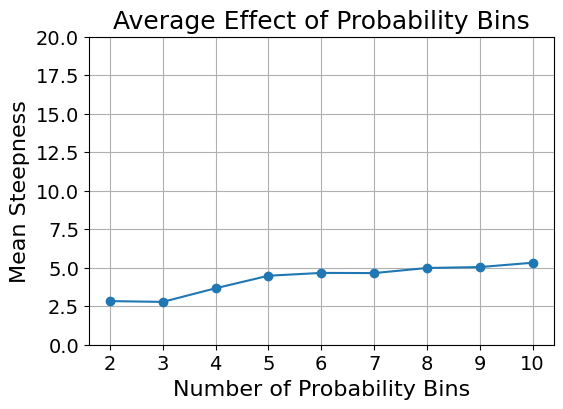

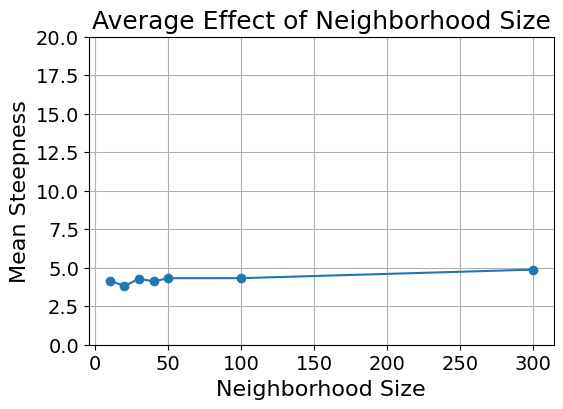

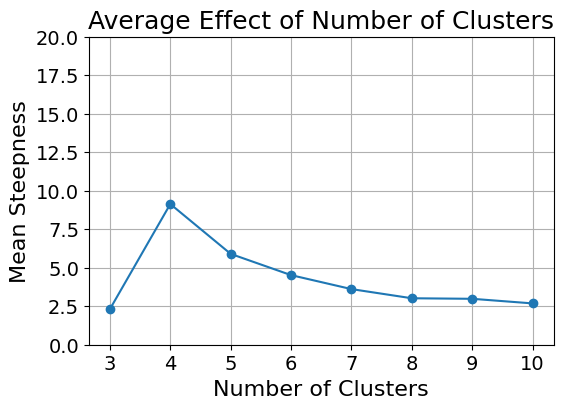

In [28]:
import matplotlib.pyplot as plt

# Font sizes
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

##############################################################
# Average steepness vs. number of bins
##############################################################

bins_summary = (
    results_df
    .groupby("Bins")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(bins_summary.index, bins_summary.values, marker="o")
plt.xlabel("Number of Probability Bins", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Probability Bins", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

##############################################################
# Average steepness vs. neighborhood size
##############################################################

window_summary = (
    results_df
    .groupby("Neighborhood_Size")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(window_summary.index, window_summary.values, marker="o")
plt.xlabel("Neighborhood Size", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Neighborhood Size", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

##############################################################
# Average steepness vs. number of clusters
##############################################################

cluster_summary = (
    results_df
    .groupby("Clusters")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(cluster_summary.index, cluster_summary.values, marker="o")
plt.xlabel("Number of Clusters", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Number of Clusters", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

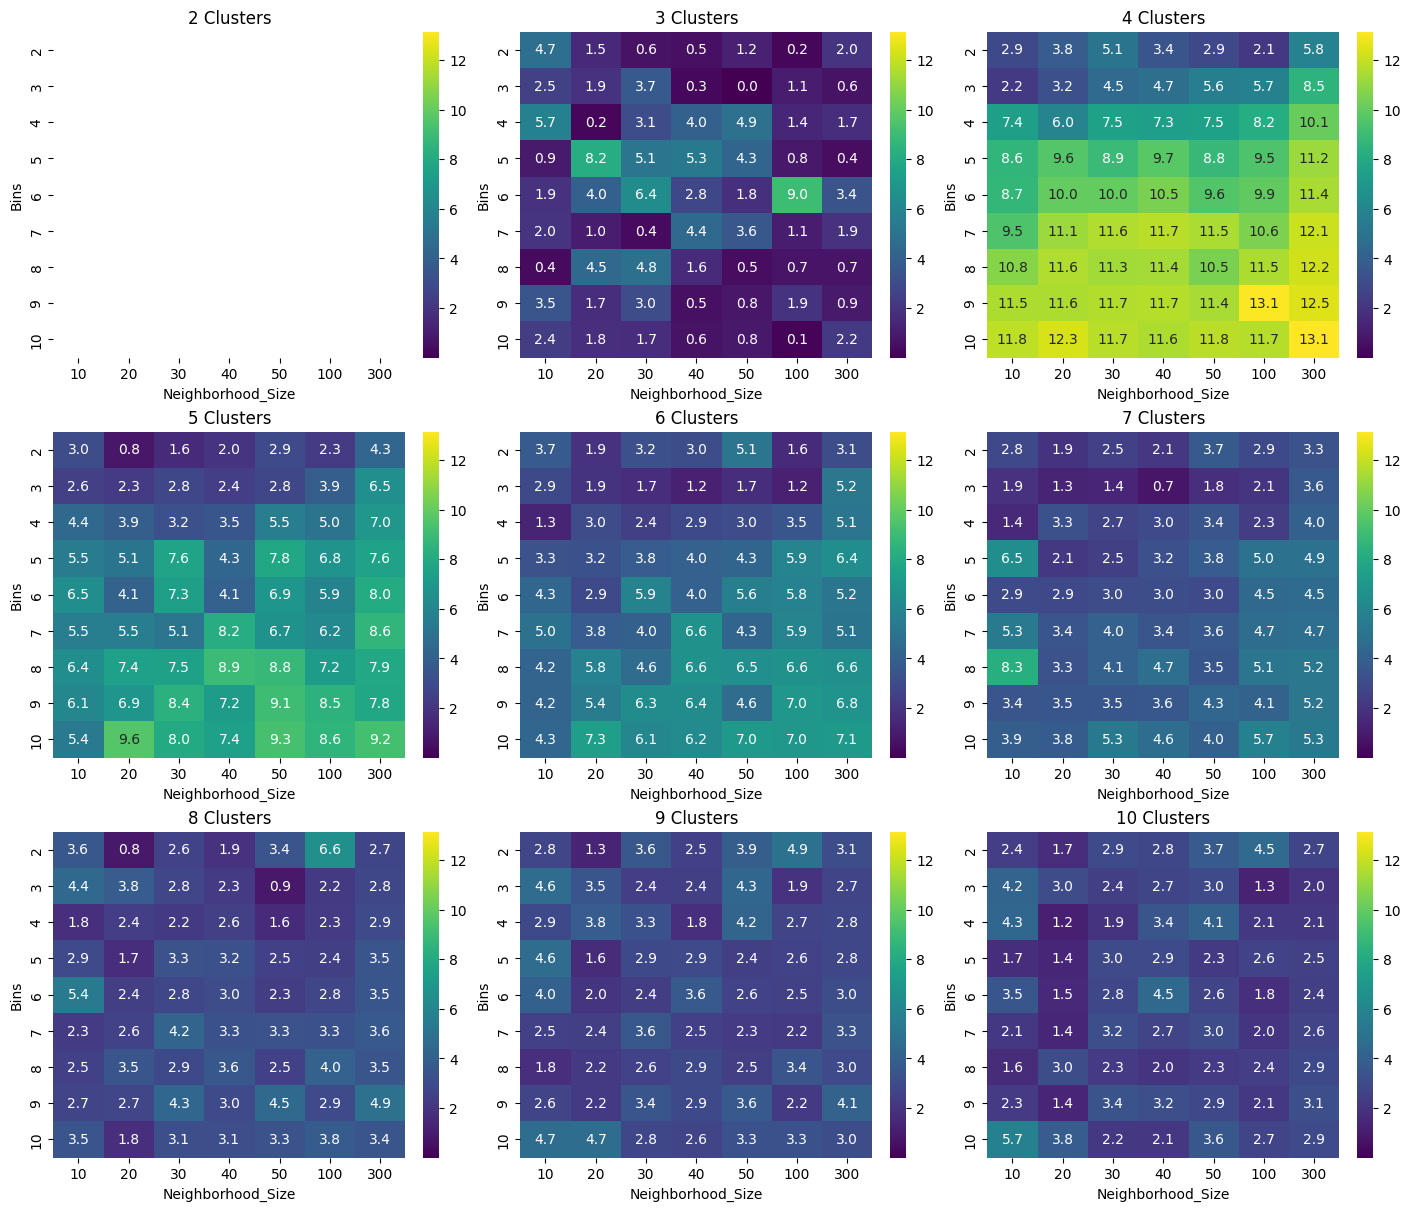

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cluster_values = sorted(results_df["Clusters"].unique())

vmin = results_df["Steepness"].min()
vmax = results_df["Steepness"].max()

fig, axes = plt.subplots(
    3,
    3,
    figsize=(14,12),
    constrained_layout=True
)

axes = axes.flatten()

for ax, c in zip(axes, cluster_values):

    pivot = (
        results_df[results_df["Clusters"] == c]
        .pivot(
            index="Bins",
            columns="Neighborhood_Size",
            values="Steepness"
        )
    )

    sns.heatmap(
        pivot,
        cmap="viridis",
        annot=True,
        fmt=".1f",
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )

    ax.set_title(f"{c} Clusters")

plt.show()

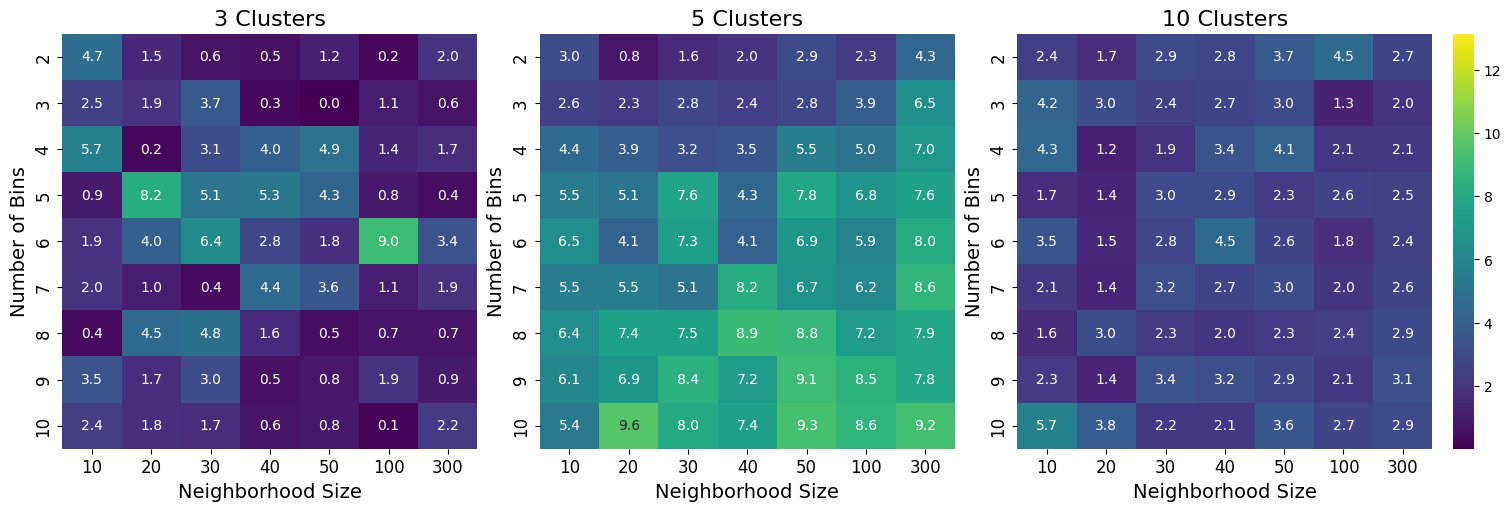

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_values = [3, 5, 10]

vmin = results_df["Steepness"].min()
vmax = results_df["Steepness"].max()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True
)

for ax, c in zip(axes, cluster_values):

    pivot = (
        results_df[results_df["Clusters"] == c]
        .pivot(
            index="Bins",
            columns="Neighborhood_Size",
            values="Steepness"
        )
    )

    sns.heatmap(
        pivot,
        cmap="viridis",
        annot=True,
        fmt=".1f",
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        cbar=(c == cluster_values[-1])  # only show one colorbar
    )

    ax.set_title(f"{c} Clusters", fontsize=16)
    ax.set_xlabel("Neighborhood Size", fontsize=14)
    ax.set_ylabel("Number of Bins", fontsize=14)
    ax.tick_params(labelsize=12)

plt.show()

Slow

In [31]:
cells, probability_df, df_score = prepare_gradient_input(
    r"Z:\MINGLE\Reviewer Response\Code\R1.5\synthetic_tissue_slow.csv"
)

print(df_score["Score"].describe())

print(df_score.head())

c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
c:\Users\k1van\anaconda3\envs\mingle-env\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWar

Example dummy cols: ['cell_type__1', 'cell_type__10', 'cell_type__11', 'cell_type__12', 'cell_type__2']
{5:                x           y  unique_region cell_type    1   10   11   12  \
0     850.585467  931.366005              1         2  0.0  0.0  0.0  1.0   
1     451.564956  166.936956              1        11  0.0  1.0  1.0  0.0   
2     248.735975  591.645276              1        12  2.0  0.0  0.0  1.0   
3     584.153406  326.727948              1         4  0.0  0.0  2.0  0.0   
4     663.688130  711.389394              1         4  1.0  0.0  0.0  0.0   
...          ...         ...            ...       ...  ...  ...  ...  ...   
3335  239.822385   29.471294              1         3  2.0  1.0  0.0  0.0   
3336  442.628147  727.556213              1         7  1.0  0.0  0.0  0.0   
3337  440.154406  240.954546              1         1  1.0  0.0  1.0  0.0   
3338    3.745708  397.898635              1        10  0.0  2.0  1.0  1.0   
3339  299.828615  844.098963              1  

In [32]:
from itertools import product
import pandas as pd

##############################################################
# Parameter ranges
##############################################################

BIN_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10]

NEIGHBORHOOD_SIZES = [
    10,
    20,
    30,
    40,
    50,
    100,
    300,
]

N_CLUSTERS = [
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
]

##############################################################

results = []

total_runs = (
    len(BIN_VALUES)
    * len(NEIGHBORHOOD_SIZES)
    * len(N_CLUSTERS)
)

run = 1

##############################################################

for n_bins, neighborhood_size, n_clusters in product(
    BIN_VALUES,
    NEIGHBORHOOD_SIZES,
    N_CLUSTERS,
):

    print(
        f"[{run}/{total_runs}] "
        f"bins={n_bins}, "
        f"window={neighborhood_size}, "
        f"clusters={n_clusters}"
    )

    ##########################################################

    df_bins, bin_edges = prepare_probability_bins(
        df_score,
        n_bins=n_bins,
    )

    ##########################################################

    try:

        df_sub, adata, stats = run_gradient_analysis(

            df_bins,

            neighborhood_size=neighborhood_size,

            n_clusters=n_clusters,
            n_bins=n_bins,

        )

        results.append({

        "Bins": n_bins,

        "Neighborhood_Size": neighborhood_size,

        "Clusters": n_clusters,

        "Slope": stats["Slope"],

        "Steepness": stats["Steepness"],

        "MeanScores": stats["MeanScores"],

        "FirstDerivative": stats["FirstDerivative"],

        "SecondDerivative": stats["SecondDerivative"],

    })

    except Exception as e:

        print("FAILED:", e)

        results.append({

            "Bins": n_bins,

            "Neighborhood_Size": neighborhood_size,

            "Clusters": n_clusters,

            "Slope": None,

            "Steepness": None,

            "MeanScores": None,

            "Error": str(e),

        })

    run += 1

##############################################################

results_df = pd.DataFrame(results)

results_df

[1/567] bins=2, window=10, clusters=2
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.009735345840454102 0.009735345840454102
k_dists: {10: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 4022.39pt/s]


[2/567] bins=2, window=10, clusters=3
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.0070264339447021484 0.0070264339447021484
k_dists: {10: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3813.66pt/s]


[3/567] bins=2, window=10, clusters=4
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.007380485534667969 0.007380485534667969
k_dists: {10: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:10--0/3340 cells had cells excluded.  Avg excluded=0


...

[566/567] bins=10, window=300, clusters=9
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.1449289321899414 0.1449289321899414
k_dists: {300: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:300--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3958.28pt/s]


[567/567] bins=10, window=300, clusters=10
Starting: 1/1 : 1
Finishing: 1/1 : 1 0.14259696006774902 0.14259696006774902
k_dists: {300: 1000} Type: <class 'dict'>
distance_max: 1000 Type: <class 'int'>
1:300--0/3340 cells had cells excluded.  Avg excluded=0


c:\Users\k1van\anaconda3\envs\mingle-env\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Local gradients (1): 100%|██████████| 3340/3340 [00:00<00:00, 3879.94pt/s]


,Bins,Neighborhood_Size,Clusters,Slope,Steepness,MeanScores,FirstDerivative,SecondDerivative
0,2,10,2,-16.814421,NaN,"[8.56433716489539, -8.25008429292109]",[-16.81442145781648],[]
1,2,10,3,-9.459427,0.635082,"[9.67392779377792, 0.5320424330412714, -9.2449...","[-9.14188536073665, -9.776967699593149]",[-0.635082338856499]
2,2,10,4,-6.688348,2.322896,"[11.284696778050224, 5.826652500516004, 0.5320...","[-5.45804427753422, -5.294610067474732, -9.776...","[0.16343421005948766, -4.482357632118417]"
3,2,10,5,-5.621603,0.271278,"[11.284696778050224, 5.826652500516004, 0.5320...","[-5.45804427753422, -5.294610067474732, -5.842...","[0.16343421005948766, -0.5474204641128981, -0...."
4,2,10,6,-4.341168,1.164313,"[11.284696778050224, 5.826652500516004, 1.3580...","[-5.45804427753422, -4.468574115918621, -4.140...","[0.989470161615599, 0.32763005365850617, 1.049..."
...,...,...,...,...,...,...,...,...
562,10,300,6,-4.813145,0.946097,"[10.930427479915537, 7.174448816788216, 1.6257...","[-3.755978663127321, -5.548694430265044, -5.62...","[-1.7927157671377234, -0.0791668502092886, 1.1..."
563,10,300,7,-3.975784,1.968873,"[11.03347890536476, 7.419562921775087, 2.10658...","[-3.6139159835896724, -5.312980807017107, -6.0...","[-1.6990648234274346, -0.7495243813280563, 3.0..."
564,10,300,8,-3.381172,1.926637,"[11.067733054278598, 7.571424118442096, 2.4787...","[-3.4963089358365025, -5.092693318981084, -5.9...","[-1.5963843831445814, -0.8591977972268641, 1.9..."
565,10,300,9,-3.158164,1.656627,"[11.774211263853708, 9.252735632840263, 6.0525...","[-2.5214756310134447, -3.20015744619457, -4.27...","[-0.6786818151811254, -1.0740287175512808, -1...."


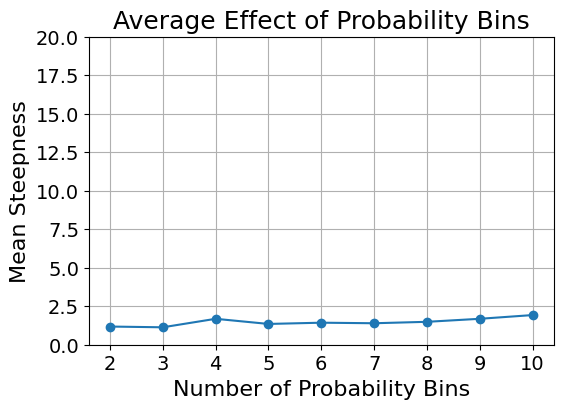

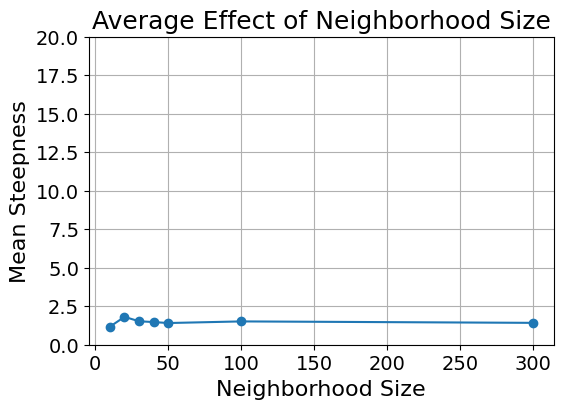

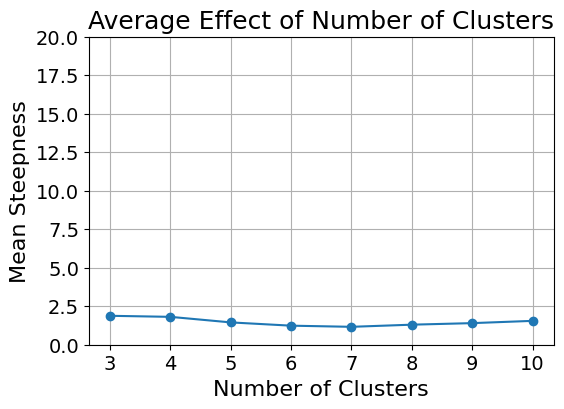

In [35]:
import matplotlib.pyplot as plt

# Font sizes
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

##############################################################
# Average steepness vs. number of bins
##############################################################

bins_summary = (
    results_df
    .groupby("Bins")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(bins_summary.index, bins_summary.values, marker="o")
plt.xlabel("Number of Probability Bins", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Probability Bins", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

##############################################################
# Average steepness vs. neighborhood size
##############################################################

window_summary = (
    results_df
    .groupby("Neighborhood_Size")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(window_summary.index, window_summary.values, marker="o")
plt.xlabel("Neighborhood Size", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Neighborhood Size", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

##############################################################
# Average steepness vs. number of clusters
##############################################################

cluster_summary = (
    results_df
    .groupby("Clusters")["Steepness"]
    .mean()
)

plt.figure(figsize=(6,4))
plt.plot(cluster_summary.index, cluster_summary.values, marker="o")
plt.xlabel("Number of Clusters", fontsize=LABEL_SIZE)
plt.ylabel("Mean Steepness", fontsize=LABEL_SIZE)
plt.title("Average Effect of Number of Clusters", fontsize=TITLE_SIZE)
plt.ylim(0, 20)
plt.xticks(fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True)
plt.show()

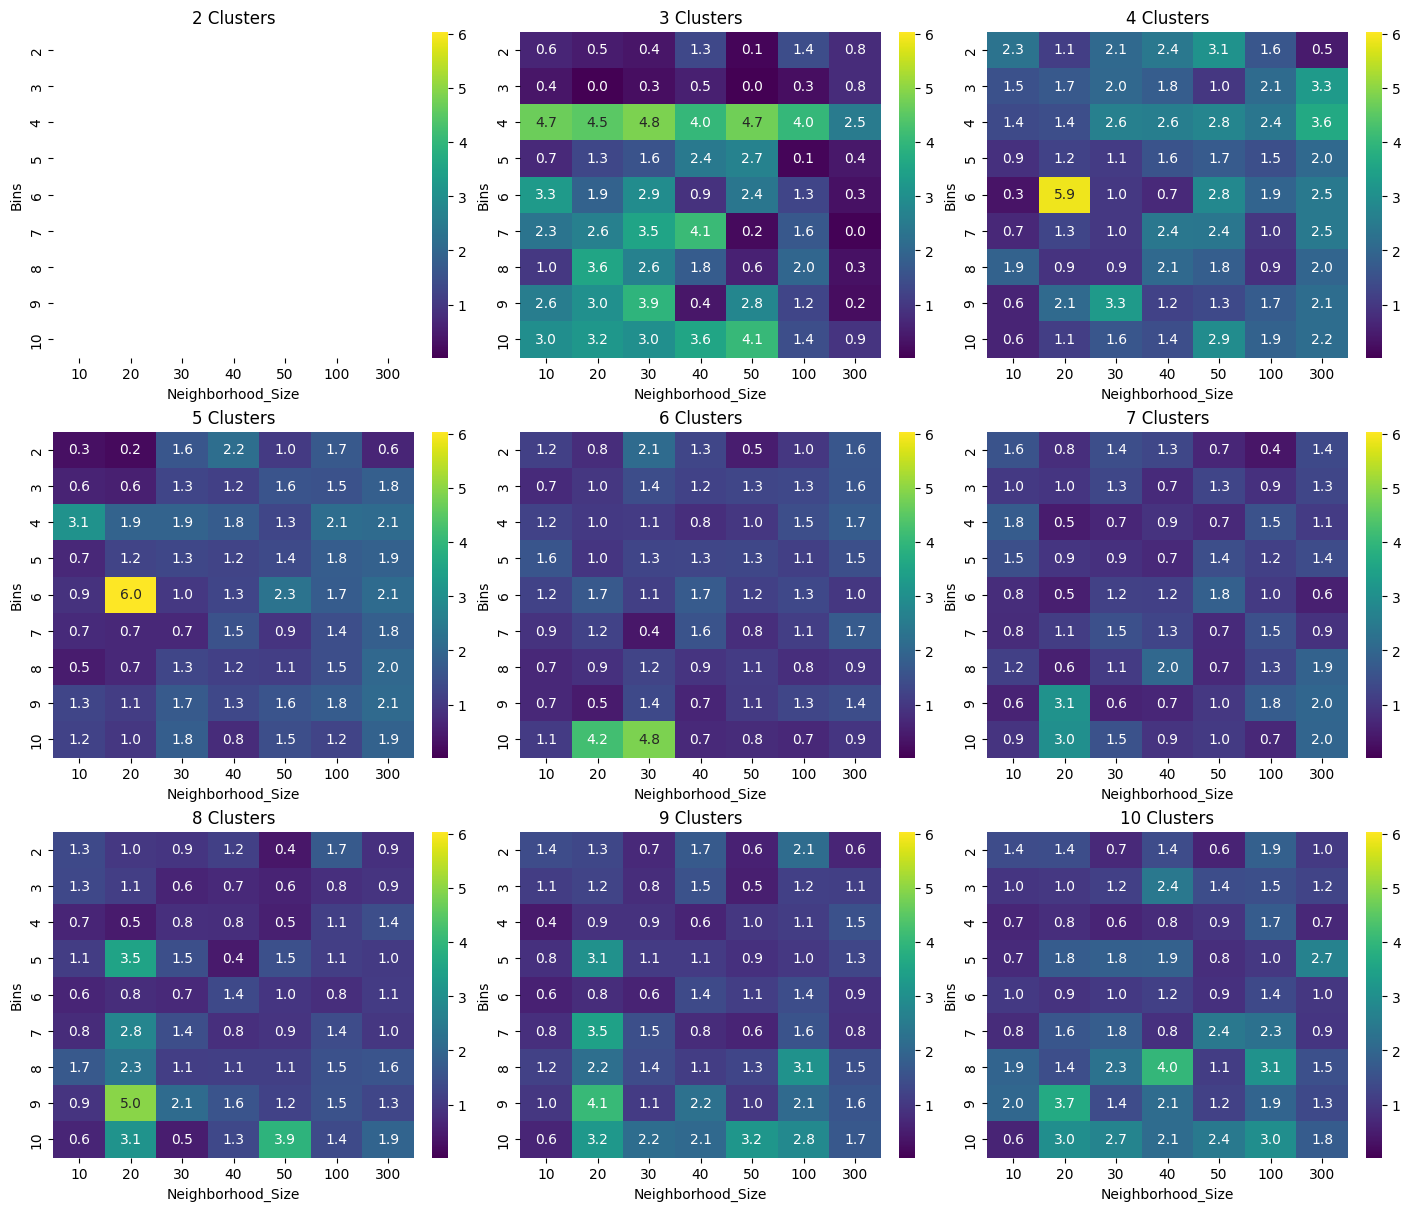

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cluster_values = sorted(results_df["Clusters"].unique())

vmin = results_df["Steepness"].min()
vmax = results_df["Steepness"].max()

fig, axes = plt.subplots(
    3,
    3,
    figsize=(14,12),
    constrained_layout=True
)

axes = axes.flatten()

for ax, c in zip(axes, cluster_values):

    pivot = (
        results_df[results_df["Clusters"] == c]
        .pivot(
            index="Bins",
            columns="Neighborhood_Size",
            values="Steepness"
        )
    )

    sns.heatmap(
        pivot,
        cmap="viridis",
        annot=True,
        fmt=".1f",
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )

    ax.set_title(f"{c} Clusters")

plt.show()

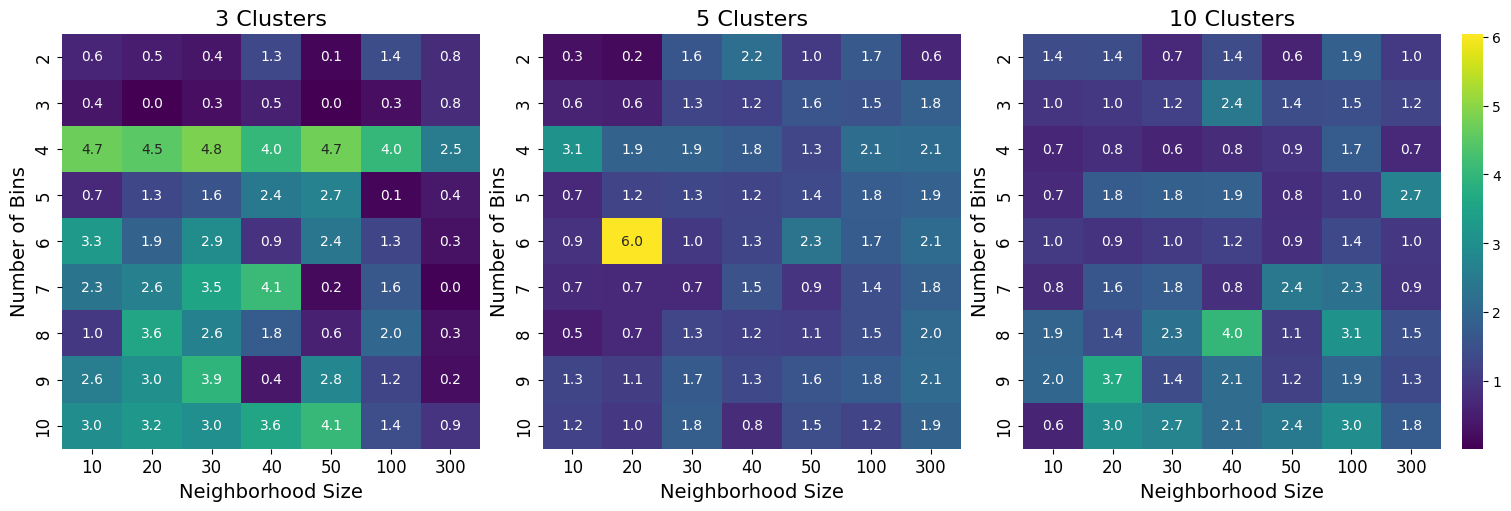

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_values = [3, 5, 10]

vmin = results_df["Steepness"].min()
vmax = results_df["Steepness"].max()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True
)

for ax, c in zip(axes, cluster_values):

    pivot = (
        results_df[results_df["Clusters"] == c]
        .pivot(
            index="Bins",
            columns="Neighborhood_Size",
            values="Steepness"
        )
    )

    sns.heatmap(
        pivot,
        cmap="viridis",
        annot=True,
        fmt=".1f",
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        cbar=(c == cluster_values[-1])  # only show one colorbar
    )

    ax.set_title(f"{c} Clusters", fontsize=16)
    ax.set_xlabel("Neighborhood Size", fontsize=14)
    ax.set_ylabel("Number of Bins", fontsize=14)
    ax.tick_params(labelsize=12)

plt.show()